# EDA — Zika Vírus SINAN 2018–2026

Analise exploratoria de dados epidemiologicos sobre Zika no Brasil.

**Seções:** Curva Epidêmica · Mapa de Calor UF×Ano · Pirãmide Etária · Gestantes e Óbitos

> Cada célula é autocontida: redefine conexão e imports antes de usar o banco.

## 1.1 Setup

In [1]:
import os
import warnings
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore')

DB_PARAMS = {
    'host':     os.getenv('PGHOST',     'localhost'),
    'port':     int(os.getenv('PGPORT', '5432')),
    'dbname':   os.getenv('PGDATABASE', 'zika'),
    'user':     os.getenv('PGUSER',     'postgres'),
    'password': os.getenv('PGPASSWORD', 'lucas01'),
}


def _query(sql):
    conn = psycopg2.connect(**DB_PARAMS)
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()


DPI = 120
FONT_SIZE = 10
plt.rcParams.update({'figure.dpi': DPI, 'font.size': FONT_SIZE})
print('Setup OK — banco:', DB_PARAMS['dbname'], '@', DB_PARAMS['host'])

Setup OK — banco: zika @ localhost


## 1.2 Curva Epidêmica

Casos confirmados por semana epidemiológica, um subplot por ano.

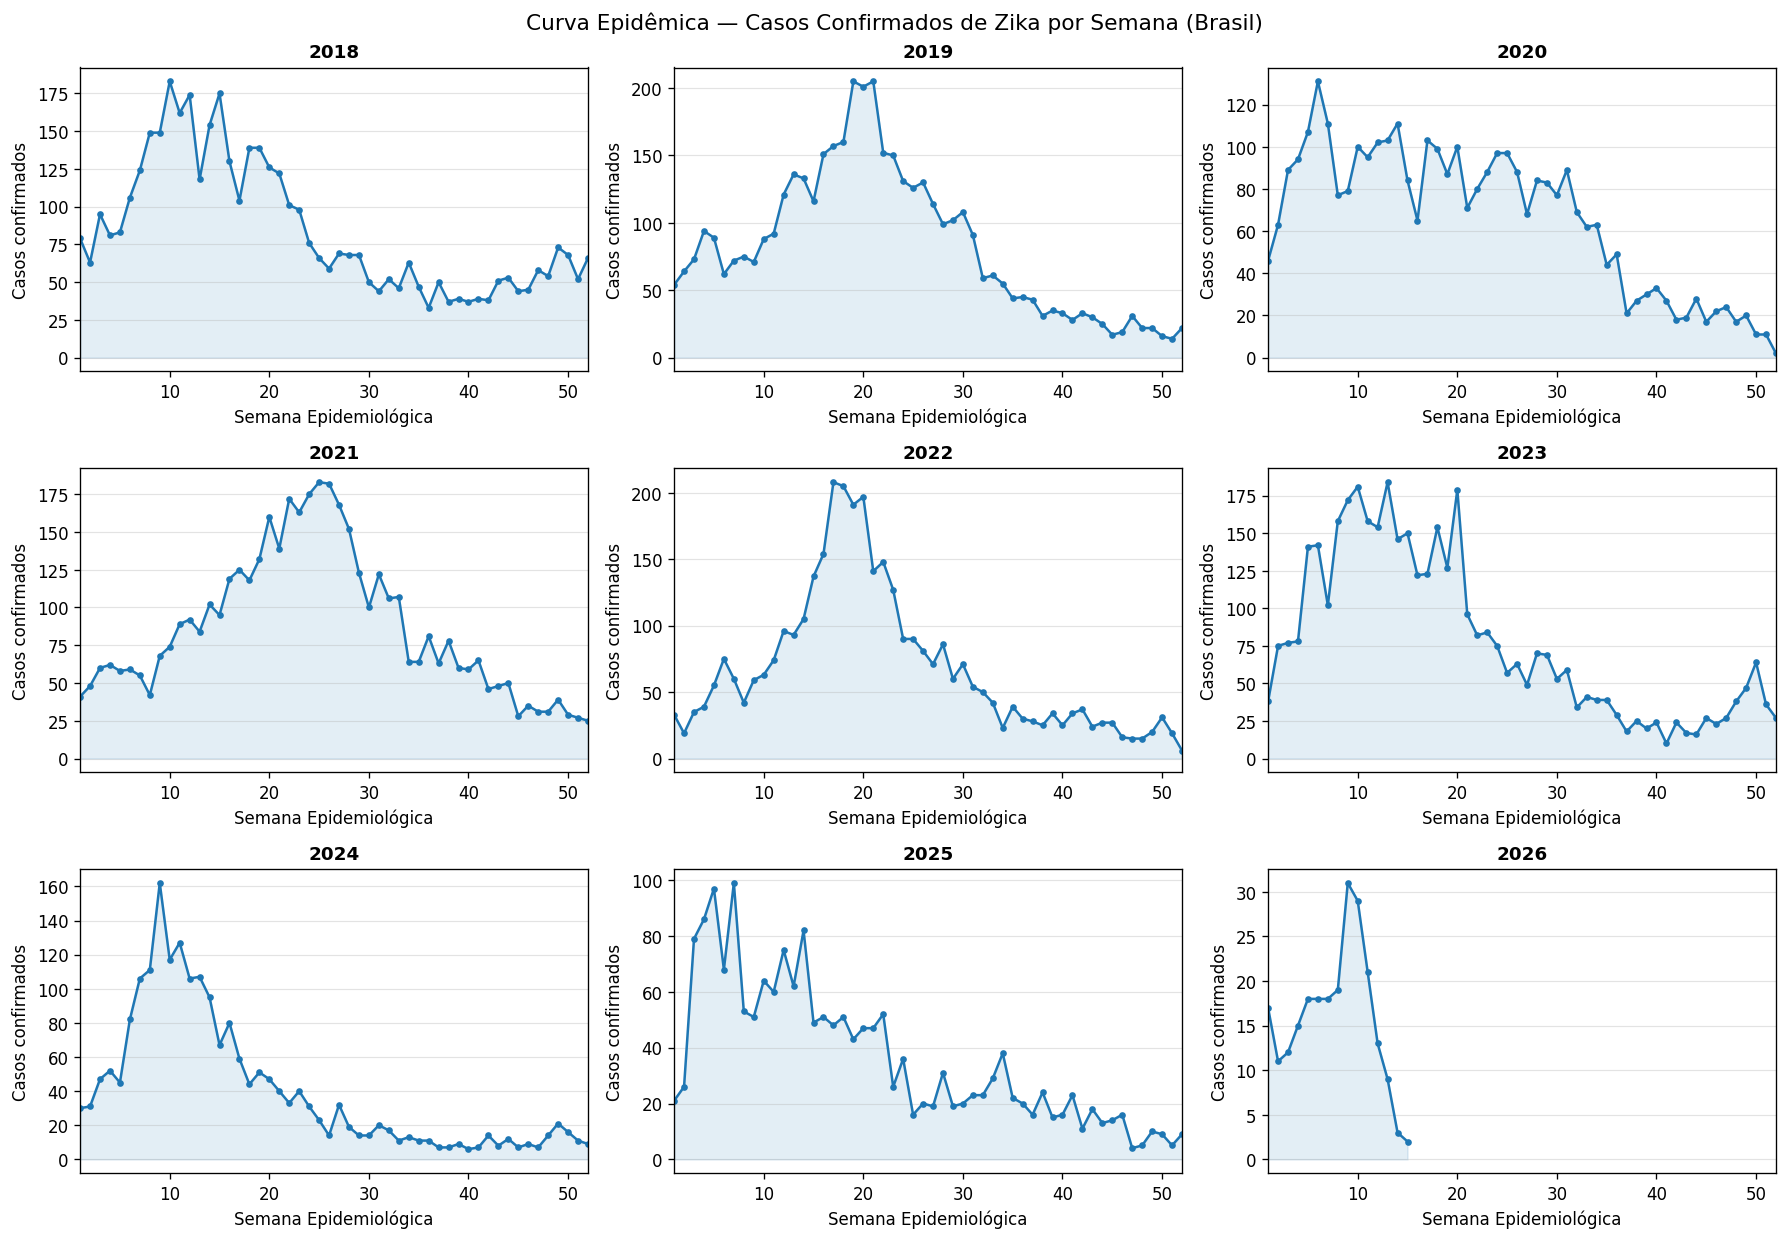

In [2]:
import os, warnings, psycopg2, numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DB_PARAMS = {
    'host':     os.getenv('PGHOST',     'localhost'),
    'port':     int(os.getenv('PGPORT', '5432')),
    'dbname':   os.getenv('PGDATABASE', 'zika'),
    'user':     os.getenv('PGUSER',     'postgres'),
    'password': os.getenv('PGPASSWORD', 'lucas01'),
}


def _query(sql):
    conn = psycopg2.connect(**DB_PARAMS)
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()


DPI = 120
FONT_SIZE = 10
plt.rcParams.update({'figure.dpi': DPI, 'font.size': FONT_SIZE})

df_sem = _query(
    'SELECT nu_ano, sem_pri, SUM(total_casos) AS total_casos'
    ' FROM sinan.vw_serie_temporal_semanal'
    ' GROUP BY nu_ano, sem_pri'
    ' ORDER BY nu_ano, sem_pri'
)

anos  = sorted(df_sem['nu_ano'].dropna().astype(int).unique())
ncols = 3
nrows = -(-len(anos) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

for i, ano in enumerate(anos):
    ax = axes[i]
    d  = df_sem[df_sem['nu_ano'] == ano].sort_values('sem_pri')
    ax.plot(d['sem_pri'], d['total_casos'], marker='o', ms=3, lw=1.5, color='#1f77b4')
    ax.fill_between(d['sem_pri'], d['total_casos'], alpha=0.12, color='#1f77b4')
    ax.set_title(str(ano), fontsize=11, fontweight='bold')
    ax.set_xlabel('Semana Epidemiológica')
    ax.set_ylabel('Casos confirmados')
    ax.set_xlim(1, 52)
    ax.grid(axis='y', alpha=0.35, lw=0.7)

for j in range(len(anos), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Curva Epidêmica — Casos Confirmados de Zika por Semana (Brasil)', fontsize=13)
fig.tight_layout()
plt.show()

## 1.3 Mapa de Calor UF x Ano

Valores normalizados por linha (% do total de cada UF) para comparar estados com volumes diferentes.

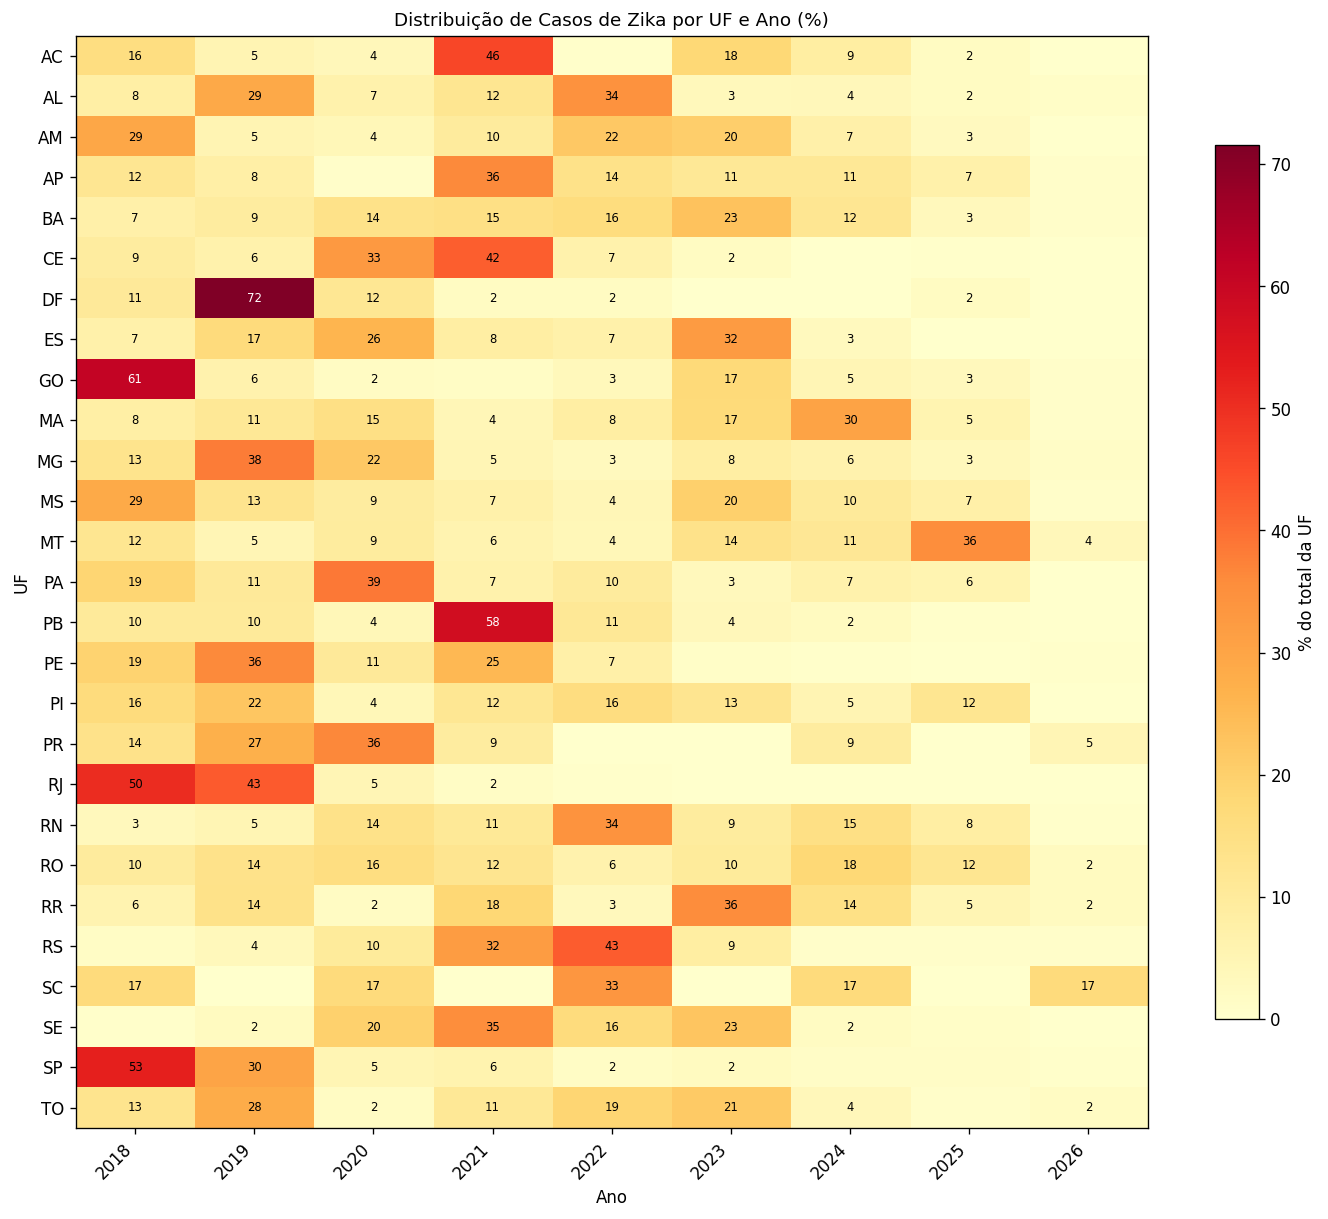

In [3]:
import os, warnings, psycopg2, numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DB_PARAMS = {
    'host':     os.getenv('PGHOST',     'localhost'),
    'port':     int(os.getenv('PGPORT', '5432')),
    'dbname':   os.getenv('PGDATABASE', 'zika'),
    'user':     os.getenv('PGUSER',     'postgres'),
    'password': os.getenv('PGPASSWORD', 'lucas01'),
}


def _query(sql):
    conn = psycopg2.connect(**DB_PARAMS)
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()


DPI = 120
FONT_SIZE = 10
plt.rcParams.update({'figure.dpi': DPI, 'font.size': FONT_SIZE})

df_uf = _query('SELECT * FROM sinan.vw_casos_uf_ano')
df_uf = df_uf.dropna(subset=['sigla_uf', 'nu_ano', 'total_casos'])
df_uf['nu_ano'] = df_uf['nu_ano'].astype(int)

pivot = df_uf.pivot_table(
    index='sigla_uf', columns='nu_ano', values='total_casos',
    aggfunc='sum', fill_value=0
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).mul(100)

rows = list(pivot_pct.index)
cols = [str(c) for c in pivot_pct.columns]

fig, ax = plt.subplots(figsize=(12, max(6, len(rows) * 0.38)))
im = ax.imshow(pivot_pct.values, aspect='auto', cmap='YlOrRd')
cb = plt.colorbar(im, ax=ax, shrink=0.8)
cb.set_label('% do total da UF')

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(rows)
ax.set_title('Distribuição de Casos de Zika por UF e Ano (%)', fontsize=11)
ax.set_xlabel('Ano')
ax.set_ylabel('UF')

for i in range(len(rows)):
    for j in range(len(cols)):
        v = pivot_pct.values[i, j]
        if v > 1.5:
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                    color='white' if v > 55 else 'black')

fig.tight_layout()
plt.show()

## 1.4 Pirãmide Etária

Casos confirmados por faixa etária e sexo. Masculino à esquerda, feminino à direita.

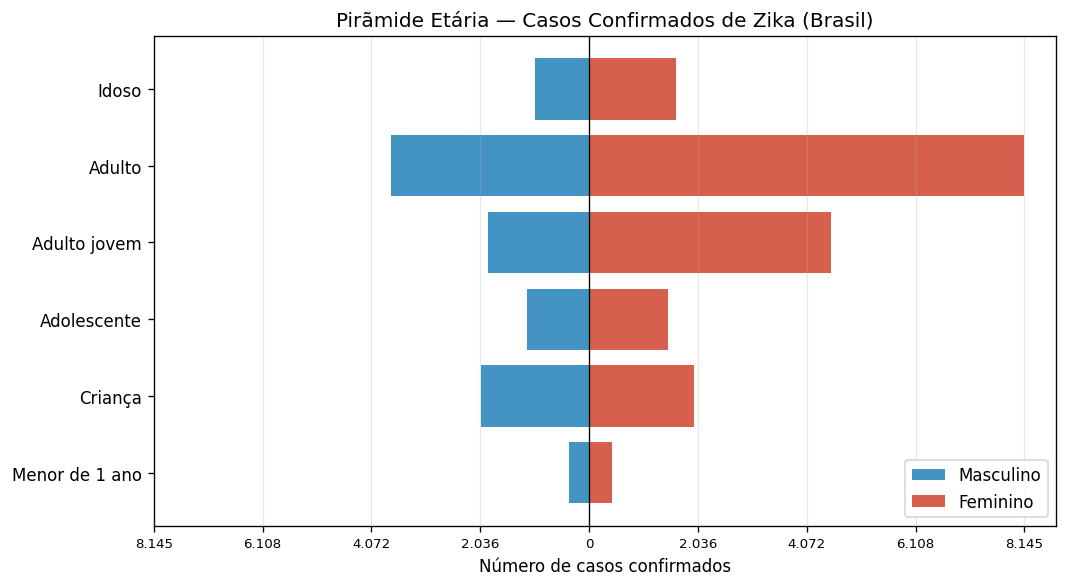

In [4]:
import os, warnings, psycopg2, numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DB_PARAMS = {
    'host':     os.getenv('PGHOST',     'localhost'),
    'port':     int(os.getenv('PGPORT', '5432')),
    'dbname':   os.getenv('PGDATABASE', 'zika'),
    'user':     os.getenv('PGUSER',     'postgres'),
    'password': os.getenv('PGPASSWORD', 'lucas01'),
}


def _query(sql):
    conn = psycopg2.connect(**DB_PARAMS)
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()


DPI = 120
FONT_SIZE = 10
plt.rcParams.update({'figure.dpi': DPI, 'font.size': FONT_SIZE})

FAIXAS = ['Menor de 1 ano', 'Criança', 'Adolescente', 'Adulto jovem', 'Adulto', 'Idoso']

df_pir = _query('SELECT * FROM sinan.vw_piramide_etaria')

pivot = (
    df_pir.pivot_table(
        index='faixa_etaria', columns='cs_sexo', values='total',
        aggfunc='sum', fill_value=0
    )
    .reindex(FAIXAS)
    .fillna(0)
)

masc = pivot.get('M', pd.Series(0, index=FAIXAS, dtype=float)).values
fem  = pivot.get('F', pd.Series(0, index=FAIXAS, dtype=float)).values

y = np.arange(len(FAIXAS))
fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(y, -masc, align='center', color='#4393c3', label='Masculino')
ax.barh(y,  fem,  align='center', color='#d6604d', label='Feminino')

ax.set_yticks(y)
ax.set_yticklabels(FAIXAS)
ax.axvline(0, color='black', lw=0.8)

max_val = max(masc.max(), fem.max())
ticks   = np.linspace(-max_val, max_val, 9)
ax.set_xticks(ticks)
ax.set_xticklabels([f'{abs(int(t)):,}'.replace(',', '.') for t in ticks], fontsize=8)
ax.set_xlabel('Número de casos confirmados')
ax.set_title('Pirãmide Etária — Casos Confirmados de Zika (Brasil)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3, lw=0.7)
fig.tight_layout()
plt.show()

## 1.5 Gestantes e Óbitos

Evolução de gestantes confirmadas por trimestre + distribuição de desfechos clínicos.

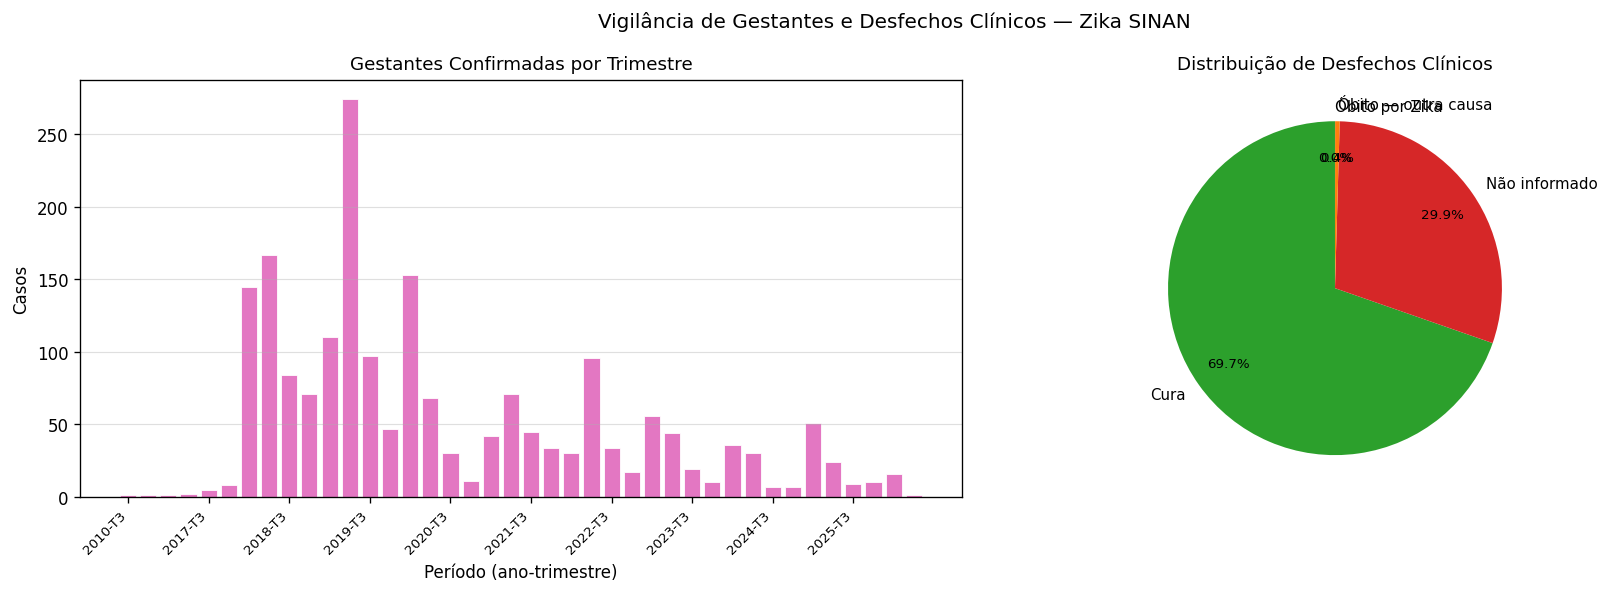

In [5]:
import os, warnings, psycopg2
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DB_PARAMS = {
    'host':     os.getenv('PGHOST',     'localhost'),
    'port':     int(os.getenv('PGPORT', '5432')),
    'dbname':   os.getenv('PGDATABASE', 'zika'),
    'user':     os.getenv('PGUSER',     'postgres'),
    'password': os.getenv('PGPASSWORD', 'lucas01'),
}


def _query(sql):
    conn = psycopg2.connect(**DB_PARAMS)
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()


DPI = 120
FONT_SIZE = 10
plt.rcParams.update({'figure.dpi': DPI, 'font.size': FONT_SIZE})

df_gest = _query('SELECT * FROM sinan.vw_vigilancia_gestantes')
df_gest['dt_sin_pri'] = pd.to_datetime(df_gest['dt_sin_pri'], errors='coerce')
df_gest = df_gest.dropna(subset=['dt_sin_pri'])
df_gest['ano'] = df_gest['dt_sin_pri'].dt.year
df_gest['tri'] = df_gest['dt_sin_pri'].dt.quarter
df_gest['periodo'] = df_gest['ano'].astype(str) + '-T' + df_gest['tri'].astype(str)

contagem = (
    df_gest.groupby(['ano', 'tri', 'periodo']).size()
    .reset_index(name='total')
    .sort_values(['ano', 'tri'])
    .reset_index(drop=True)
)

df_ev = _query('SELECT evolucao, COUNT(*) AS total FROM sinan.evolucao_clinica GROUP BY evolucao')
LABELS = {1: 'Cura', 2: 'Óbito por Zika', 3: 'Óbito — outra causa'}
df_ev['label'] = df_ev['evolucao'].map(LABELS).fillna('Não informado')
df_ev_grp = (
    df_ev.groupby('label', as_index=False)['total'].sum()
    .sort_values('total', ascending=False)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.bar(range(len(contagem)), contagem['total'], color='#e377c2', edgecolor='white', lw=0.5)
step = max(1, len(contagem) // 10)
ax1.set_xticks(range(0, len(contagem), step))
ax1.set_xticklabels(contagem['periodo'].iloc[::step], rotation=45, ha='right', fontsize=8)
ax1.set_title('Gestantes Confirmadas por Trimestre', fontsize=11)
ax1.set_xlabel('Período (ano-trimestre)')
ax1.set_ylabel('Casos')
ax1.grid(axis='y', alpha=0.4, lw=0.7)

colors = ['#2ca02c', '#d62728', '#ff7f0e', '#7f7f7f', '#aec7e8'][:len(df_ev_grp)]
wedges, texts, autotexts = ax2.pie(
    df_ev_grp['total'], labels=df_ev_grp['label'],
    autopct='%1.1f%%', colors=colors, startangle=90, pctdistance=0.78,
)
for t in texts: t.set_fontsize(9)
for at in autotexts: at.set_fontsize(8)
ax2.set_title('Distribuição de Desfechos Clínicos', fontsize=11)

fig.suptitle('Vigilância de Gestantes e Desfechos Clínicos — Zika SINAN', fontsize=12)
fig.tight_layout()
plt.show()